In [ ]:
# Install necessary system packages and Python libraries
!apt install --allow-change-held-packages libcudnn8=8.6.0.163-1+cuda11.8 -y
!pip install einops tensorflow_text tensorflow_datasets nltk rouge

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libcudnn8 is already the newest version (8.6.0.163-1+cuda11.8).
0 upgraded, 0 newly installed, 0 to remove and 18 not upgraded.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import string
import re
import collections
import tqdm

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small

from google.colab.patches import cv2_imshow
import cv2

import einops
import nltk
nltk.download('wordnet')
from nltk.translate import meteor_score
from nltk.translate.bleu_score import corpus_bleu
from rouge import Rouge

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


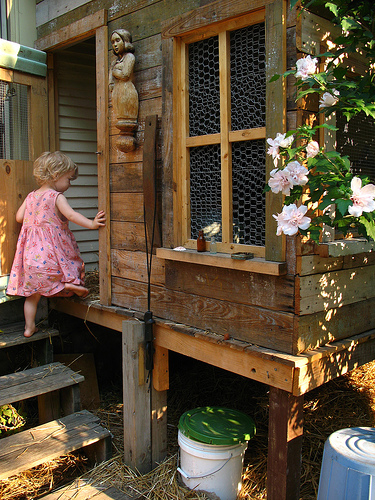

In [ ]:
def flickr8k(path='flickr8k'):
    base_path = pathlib.Path(path)
    if len(list(base_path.rglob('*'))) < 16197:
        tf.keras.utils.get_file(
            origin='https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip',
            cache_dir='.',
            cache_subdir=path,
            extract=True)
        tf.keras.utils.get_file(
            origin='https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip',
            cache_dir='.',
            cache_subdir=path,
            extract=True)

    caption_file = base_path / "Flickr8k_text.zip/Flickr8k.token.txt"
    captions_lines = caption_file.read_text().splitlines()
    cap_dict = collections.defaultdict(list)
    for line in captions_lines:
        fname, cap = line.split('\t')
        fname = fname.split('#')[0]
        cap_dict[fname].append(cap)

    for fname in cap_dict:
        cap_dict[fname] = tf.convert_to_tensor(cap_dict[fname], dtype=tf.string)

    train_files = (base_path / 'Flickr8k_text.zip/Flickr_8k.trainImages.txt').read_text().splitlines()
    test_files = (base_path / 'Flickr8k_text.zip/Flickr_8k.testImages.txt').read_text().splitlines()
    validation_files = (base_path / 'Flickr8k_text.zip/Flickr_8k.devImages.txt').read_text().splitlines()

    def make_dataset(file_list):
        return [
            (str(base_path / 'Flickr8k_Dataset.zip/Flicker8k_Dataset' / fname), cap_dict[fname])
            for fname in file_list
        ]

    train_captions = make_dataset(train_files)
    test_captions = make_dataset(test_files)
    validation_captions = make_dataset(validation_files)

    train_image_paths, train_caps = zip(*train_captions)
    test_image_paths, test_caps = zip(*test_captions)
    val_image_paths, val_caps = zip(*validation_captions)

    train_ds = tf.data.Dataset.from_tensor_slices((list(train_image_paths), list(train_caps)))
    test_ds = tf.data.Dataset.from_tensor_slices((list(test_image_paths), list(test_caps)))
    validation_ds = tf.data.Dataset.from_tensor_slices((list(val_image_paths), list(val_caps)))

    sample_fname = list(cap_dict.keys())[0]
    sample_img_path = str(base_path / 'Flickr8k_Dataset.zip/Flicker8k_Dataset' / sample_fname)
    sample_img = cv2.imread(sample_img_path)
    cv2_imshow(sample_img)

    return base_path, train_ds, test_ds, validation_ds, test_files, cap_dict

base_path, train_raw, test_raw, validation_raw, test_images, cap_dict = flickr8k()

In [ ]:
IMAGE_SHAPE = (224, 224, 3)

mobilenet = MobileNetV3Small(
    input_shape=IMAGE_SHAPE,
    include_top=False,
    include_preprocessing=True)
mobilenet.trainable = False
mobilenet.summary()

def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SHAPE[:2])
    return img

for sample_path, sample_caps in train_raw.take(1):
    sample_path = sample_path.numpy().decode()
    break
test_img_batch = load_image(sample_path)[tf.newaxis, :]
print("Test image batch shape:", test_img_batch.shape)

Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv (Conv2D)             │ (None, 112, 112, 16)   │            432 │ rescaling[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_bn                   │ (None, 112, 112, 16)   │             64 │ conv[0][0]             │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 112, 112, 16)   │              0 │ conv_bn[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 113, 113, 16)   │              0 │ activation[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 56, 56, 16)     │            144 │ expanded_conv_depthwi… │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 56, 56, 16)     │             64 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu (ReLU)              │ (None, 56, 56, 16)     │              0 │ expanded_conv_depthwi… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 16)       │              0 │ re_lu[0][0]            │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 8)        │            136 │ expanded_conv_squeeze… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 8)        │              0 │ expanded_conv_squeeze… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 16)       │            144 │ expanded_conv_squeeze… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 1, 1, 16)       │              0 │ expanded_conv_squeeze… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_1 (ReLU)            │ (None, 1, 1, 16)       │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)  

 Total params: 939,120 (3.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 939,120 (3.58 MB)

Test image batch shape: (1, 224, 224, 3)


In [ ]:
def standardize(s):
    s = tf.strings.lower(s)
    s = tf.strings.regex_replace(s, f'[{re.escape(string.punctuation)}]', '')
    s = tf.strings.join(['[START]', s, '[END]'], separator=' ')
    return s

vocabulary_size = 5000
tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=vocabulary_size,
    standardize=standardize,
    ragged=True)

train_captions_ds = train_raw.map(lambda fp, caps: caps).unbatch().batch(1024)
tokenizer.adapt(train_captions_ds)
print("First 10 tokens of the vocabulary:", tokenizer.get_vocabulary()[:10])

word_to_index_lookup = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary())
index_to_word_lookup = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary(),
    invert=True)

First 10 tokens of the vocabulary: ['', '[UNK]', 'a', '[START]', '[END]', 'in', 'the', 'on', 'is', 'and']


In [ ]:
def match_shapes(images, captions):
    caption_shape = einops.parse_shape(captions, 'b c')
    captions = einops.rearrange(captions, 'b c -> (b c)')
    images = einops.repeat(images, 'b ... -> (b c) ...', c=caption_shape['c'])
    return images, captions

In [ ]:
def prepare_txt(imgs, txts):
    tokens = tokenizer(txts)
    input_tokens = tokens[..., :-1]
    label_tokens = tokens[..., 1:]
    return (imgs, input_tokens), label_tokens

def prepare_dataset(ds, batch_size=32, shuffle_buffer=1000):
    ds = ds.shuffle(10000)
    ds = ds.map(lambda path, caption: (load_image(path), caption),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.map(lambda images, captions: match_shapes(images, captions),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.unbatch().shuffle(shuffle_buffer).batch(batch_size)
    ds = ds.map(prepare_txt, num_parallel_calls=tf.data.AUTOTUNE)

    def to_tensor(inputs, labels):
        (images, in_tok), out_tok = inputs, labels
        return (images, in_tok.to_tensor()), out_tok.to_tensor()

    ds = ds.map(to_tensor, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = prepare_dataset(train_raw)
test_ds = prepare_dataset(test_raw)
validation_ds = prepare_dataset(validation_raw)

In [ ]:
class SeqEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, max_length, depth):
        super().__init__()
        self.pos_embedding = tf.keras.layers.Embedding(input_dim=max_length, output_dim=depth)
        self.token_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=depth,
            mask_zero=True)
        self.add = tf.keras.layers.Add()

    def call(self, seq):
        token_emb = self.token_embedding(seq)
        positions = tf.range(tf.shape(seq)[1])
        pos_emb = self.pos_embedding(positions[tf.newaxis, :])
        return self.add([token_emb, pos_emb])

class CausalSelfAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.add = tf.keras.layers.Add()
        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x):
        attn = self.mha(query=x, value=x, use_causal_mask=True)
        x = self.add([x, attn])
        return self.layernorm(x)

class CrossAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.add = tf.keras.layers.Add()
        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x, y):
        attn, attention_scores = self.mha(query=x, value=y, return_attention_scores=True)
        self.last_attention_scores = attention_scores
        x = self.add([x, attn])
        return self.layernorm(x)

class FeedForward(tf.keras.layers.Layer):
    def __init__(self, units, dropout_rate=0.1):
        super().__init__()
        self.seq = tf.keras.Sequential([
            tf.keras.layers.Dense(units=2 * units, activation='relu'),
            tf.keras.layers.Dense(units=units),
            tf.keras.layers.Dropout(rate=dropout_rate)
        ])
        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x):
        x = x + self.seq(x)
        return self.layernorm(x)

class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, units, num_heads=1, dropout_rate=0.1):
        super().__init__()
        self.self_attention = CausalSelfAttention(num_heads=num_heads, key_dim=units, dropout=dropout_rate)
        self.cross_attention = CrossAttention(num_heads=num_heads, key_dim=units, dropout=dropout_rate)
        self.ff = FeedForward(units=units, dropout_rate=dropout_rate)

    def call(self, inputs):
        encoder_output, decoder_tokens = inputs
        x = self.self_attention(decoder_tokens)
        x = self.cross_attention(x, encoder_output)
        self.last_attention_scores = self.cross_attention.last_attention_scores
        x = self.ff(x)
        return x

class TokenOutput(tf.keras.layers.Layer):
    def __init__(self, tokenizer, banned_tokens=('', '[UNK]', '[START]'), **kwargs):
        super().__init__()
        self.dense = tf.keras.layers.Dense(units=tokenizer.vocabulary_size(), **kwargs)
        self.tokenizer = tokenizer
        self.banned_tokens = banned_tokens
        self.bias = None

    def adapt(self, ds):
        counts = collections.Counter()
        vocab = self.tokenizer.get_vocabulary()
        vocab_dict = {name: id for id, name in enumerate(vocab)}
        for tokens in tqdm.tqdm(ds):
            counts.update(tokens.numpy().flatten())
        counts_arr = np.zeros((len(vocab),), dtype=np.float32)
        for token_id, count in counts.items():
            counts_arr[int(token_id)] = count
        for token in self.banned_tokens:
            counts_arr[vocab_dict[token]] = 0
        total = counts_arr.sum()
        p = counts_arr / total
        p[counts_arr == 0] = 1.0
        log_p = np.log(p)
        entropy = -(log_p * p).sum()
        print(f"Uniform entropy: {np.log(len(vocab)):.2f}")
        print(f"Marginal entropy: {entropy:.2f}")
        self.bias = log_p
        self.bias[counts_arr == 0] = -1e9

    def call(self, x):
        x = self.dense(x)
        return x + self.bias

In [ ]:
class Captioner(tf.keras.Model):
    def __init__(self, tokenizer, feature_extractor, output_layer,
                 num_layers=2, units=256, max_length=50, num_heads=2, dropout_rate=0.1):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.tokenizer = tokenizer
        self.seq_embedding = SeqEmbedding(vocab_size=tokenizer.vocabulary_size(),
                                          max_length=max_length,
                                          depth=units)
        self.decoder_layers = [DecoderLayer(units, num_heads=num_heads, dropout_rate=dropout_rate)
                               for _ in range(num_layers)]
        self.output_layer = output_layer
        self.word_to_index = tf.keras.layers.StringLookup(mask_token="",
                                                           vocabulary=tokenizer.get_vocabulary())
        self.index_to_word = tf.keras.layers.StringLookup(mask_token="",
                                                           vocabulary=tokenizer.get_vocabulary(),
                                                           invert=True)
        self.max_length = max_length

    def call(self, inputs):
        image, txt = inputs
        if image.shape[-1] == 3:
            image = self.feature_extractor(image)
            image = einops.rearrange(image, 'b h w c -> b (h w) c')
        x = self.seq_embedding(txt)
        for layer in self.decoder_layers:
            x = layer((image, x))
        logits = self.output_layer(x)
        return logits

    def simple_gen(self, image, temperature=1.0):
        image = tf.expand_dims(image, axis=0)
        start_token = int(self.word_to_index('[START]').numpy())
        tokens = tf.constant([[start_token]], dtype=tf.int32)

        for _ in range(self.max_length):
            preds = self((image, tokens))
            preds = preds[:, -1, :]
            if temperature == 0:
                next_token = tf.argmax(preds, axis=-1, output_type=tf.int32)
                next_token = tf.expand_dims(next_token, axis=1)
            else:
                next_token = tf.random.categorical(preds / temperature, num_samples=1)
                next_token = tf.cast(next_token, tf.int32)

            tokens = tf.concat([tf.cast(tokens, tf.int32), tf.cast(next_token, tf.int32)], axis=1)

            if int(next_token[0, 0].numpy()) == int(self.word_to_index('[END]').numpy()):
                break

        token_list = tokens[0].numpy()
        words = [self.index_to_word(token).numpy().decode('utf-8') for token in token_list]
        if words[0] == '[START]':
            words = words[1:]
        if words and words[-1] == '[END]':
            words = words[:-1]
        caption = " ".join(words)
        return caption

    def run_and_show_attention(self, image, temperature=0.0):
        caption = self.simple_gen(image, temperature)
        tokens = caption.split()
        tokens.append('[END]')

        attn_maps = [layer.last_attention_scores for layer in self.decoder_layers
                 if hasattr(layer, 'last_attention_scores')]
        if not attn_maps:
            print("No attention maps available.")
            return caption
        attn_maps = tf.concat(attn_maps, axis=0)
        attention_maps = einops.reduce(attn_maps, 'batch heads seq (h w) -> seq h w', h=7, w=7, reduction='mean')

        num_attn = attention_maps.shape[0]
        num_tokens = len(tokens)
        n = min(num_attn, num_tokens)

        fig = plt.figure(figsize=(16, 9))
        for i in range(n):
            token = tokens[i]
            ax = fig.add_subplot(3, max(int(np.ceil(n/3)), 1), i+1)
            ax.set_title(token)
            img_disp = ax.imshow(image/255)
            ax.imshow(attention_maps[i], cmap='gray', alpha=0.6, extent=img_disp.get_extent())
        plt.suptitle(caption, y=1.05)
        plt.tight_layout()
        plt.show()
        print("Generated Caption:", caption)
        return caption

In [ ]:
output_layer = TokenOutput(tokenizer, banned_tokens=('', '[UNK]', '[START]'))
train_labels_ds = train_ds.map(lambda inputs, labels: labels)
output_layer.adapt(train_labels_ds)

938it [00:44, 21.03it/s]

Uniform entropy: 8.52
Marginal entropy: 5.29


In [ ]:
def masked_loss(labels, preds):
    labels = tf.cast(labels, tf.int32)
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=preds)
    mask = tf.cast(tf.math.not_equal(labels, 0), loss.dtype)
    loss = loss * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_acc(labels, preds):
    mask = tf.cast(tf.math.not_equal(labels, 0), tf.float32)
    preds = tf.argmax(preds, axis=-1, output_type=tf.int32)
    labels = tf.cast(labels, tf.int32)
    match = tf.cast(tf.equal(preds, labels), tf.float32)
    acc = tf.reduce_sum(match * mask) / tf.reduce_sum(mask)
    return acc

In [ ]:
model = Captioner(tokenizer=tokenizer,
                  feature_extractor=mobilenet,
                  output_layer=output_layer,
                  num_layers=2,
                  units=256,
                  dropout_rate=0.5,
                  num_heads=2,
                  max_length=50)

dummy_image = tf.random.uniform((1, *IMAGE_SHAPE))
dummy_text = tf.constant([[
    int(word_to_index_lookup('[START]').numpy()),
    int(word_to_index_lookup('a').numpy()),
    int(word_to_index_lookup('[END]').numpy())
]])

model((dummy_image, dummy_text))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'captioner', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "captioner"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)        │ (None, 7, 7, 576)           │         939,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ text_vectorization                   │ (None, None)                │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ seq_embedding (SeqEmbedding)         │ ?                           │       1,292,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_layer (DecoderLayer)         │ ?                           │       1,644,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_layer_1 (DecoderLayer)       │ ?                           │       1,644,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ token_output (TokenOutput)           │ ?                           │       1,285,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ string_lookup_3 (StringLookup)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ string_lookup_4 (StringLookup)       │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,805,496 (25.96 MB)

 Trainable params: 5,866,376 (22.38 MB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
class GenerateTextCallback(tf.keras.callbacks.Callback):
    def __init__(self, caption_model, sample_image):
        super().__init__()
        self.caption_model = caption_model
        self.sample_image = sample_image

    def on_epoch_end(self, epoch, logs=None):
        print("\nEpoch {}:".format(epoch+1))
        for temp in (0.0, 0.5, 1.0):
            caption = self.caption_model.simple_gen(self.sample_image, temperature=temp)
            print(f"Temperature {temp}: {caption}")
        print()

for sample_path, sample_caps in train_raw.take(1):
    sample_path = sample_path.numpy().decode()
    break
sample_img = load_image(sample_path)

gen_callback = GenerateTextCallback(model, sample_img)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss=masked_loss,
              metrics=[masked_acc])

history = model.fit(train_ds.repeat(),
                    steps_per_epoch=188,
                    validation_data=validation_ds.repeat(),
                    validation_steps=32,
                    epochs=10,
                    callbacks=[gen_callback])

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 6873735.0000 - masked_acc: 0.2161
Epoch 1:


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Temperature 0.0: a dog is running in the water
Temperature 0.5: a dog in a ball
Temperature 1.0: a drink an stick in walking in front running walking the each sits

188/188 ━━━━━━━━━━━━━━━━━━━━ 45s 142ms/step - loss: 6875622.5000 - masked_acc: 0.2163 - val_loss: 18181736.0000 - val_masked_acc: 0.2839
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 7969771.0000 - masked_acc: 0.2979
Epoch 2:
Temperature 0.0: a dog is running in the snow
Temperature 0.5: a black dog is running in the snow
Temperature 1.0: a black and black dog is running through a snow

188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - loss: 7969001.0000 - masked_acc: 0.2980 - val_loss: 15586738.0000 - val_masked_acc: 0.3164
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 8428968.0000 - masked_acc: 0.3235
Epoch 3:
Temperature 0.0: a black dog is running through the snow
Temperature 0.5: two dogs are running in water
Temperature 1.0: a black dogs in the snow

188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 212ms/ste

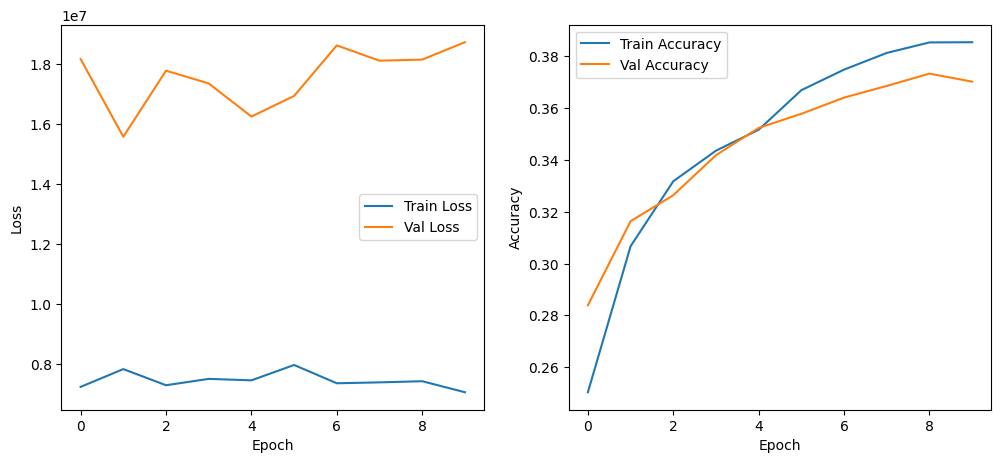

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['masked_acc'], label='Train Accuracy')
plt.plot(history.history['val_masked_acc'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [1]:
generated_caption = model.simple_gen(sample_img, temperature=0.0)
print("Generated Caption:", generated_caption)
model.run_and_show_attention(sample_img, temperature=0.0)

In [ ]:
def evaluate_captions(reference_captions, generated_caption):
    gen_tokens = generated_caption.split()

    meteor_scores = [meteor_score.single_meteor_score(ref.numpy().decode('utf-8').split(), gen_tokens)
                     for ref in reference_captions]
    max_meteor = max(meteor_scores)

    references_tokenized = [ref.numpy().decode('utf-8').split() for ref in reference_captions]
    bleu_1 = corpus_bleu([references_tokenized], [gen_tokens], weights=(1, 0, 0, 0))
    bleu_2 = corpus_bleu([references_tokenized], [gen_tokens], weights=(0.5, 0.5, 0, 0))
    bleu_3 = corpus_bleu([references_tokenized], [gen_tokens], weights=(0.33, 0.33, 0.33, 0))
    bleu_4 = corpus_bleu([references_tokenized], [gen_tokens], weights=(0.25, 0.25, 0.25, 0.25))

    references_combined = " ".join([ref.numpy().decode('utf-8') for ref in reference_captions])
    rouge_evaluator = Rouge(metrics=["rouge-1"])
    rouge_scores = rouge_evaluator.get_scores(generated_caption, references_combined, avg=True)
    rouge_l_f1 = rouge_scores['rouge-1']['f']

    return max_meteor, bleu_1, bleu_2, bleu_3, bleu_4, rouge_l_f1

In [1]:
total_meteor = 0
total_bleu_1 = 0
total_bleu_2 = 0
total_bleu_3 = 0
total_bleu_4 = 0
total_rouge_l_f1 = 0

counter = 0

for image_name in test_images:
    img_path = base_path / 'Flickr8k_Dataset.zip/Flicker8k_Dataset' / image_name
    img = load_image(str(img_path))
    references = cap_dict[image_name]

    model.run_and_show_attention(img, temperature=0.0)

    gen_caption = model.simple_gen(img, temperature=0.0)

    met, b1, b2, b3, b4, rouge_f1 = evaluate_captions(references, gen_caption)
    total_meteor += met
    total_bleu_1 += b1
    total_bleu_2 += b2
    total_bleu_3 += b3
    total_bleu_4 += b4
    total_rouge_l_f1 += rouge_f1
    counter += 1

if counter > 0:
    avg_meteor = total_meteor / counter
    avg_bleu_1 = total_bleu_1 / counter
    avg_bleu_2 = total_bleu_2 / counter
    avg_bleu_3 = total_bleu_3 / counter
    avg_bleu_4 = total_bleu_4 / counter
    avg_rouge_l_f1 = total_rouge_l_f1 / counter
else:
    avg_meteor = avg_bleu_1 = avg_bleu_2 = avg_bleu_3 = avg_bleu_4 = avg_rouge_l_f1 = 0

In [1]:
print("Average METEOR :", avg_meteor)
print("Average BLEU-1 :", avg_bleu_1)
print("Average BLEU-2 :", avg_bleu_2)
print("Average BLEU-3 :", avg_bleu_3)
print("Average BLEU-4 :", avg_bleu_4)
print("Average ROUGE-L F1 :", avg_rouge_l_f1)

Average METEOR : 0.32
Average BLEU-1 : 0.51
Average BLEU-2 : 0.29
Average BLEU-3 : 0.12
Average BLEU-4 : 0.05
Average ROUGE-L F1 : 0.26


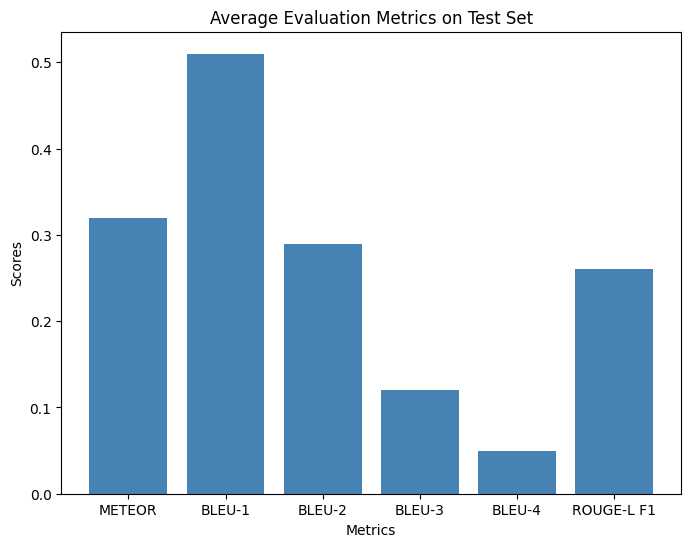

In [1]:
metrics_names = ['METEOR', 'BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'ROUGE-L F1']
avg_scores = [avg_meteor, avg_bleu_1, avg_bleu_2, avg_bleu_3, avg_bleu_4, avg_rouge_l_f1]
plt.figure(figsize=(8, 6))
plt.bar(metrics_names, avg_scores)
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Average Evaluation Metrics on Test Set')
plt.show()